# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [3]:
import numpy as np
expressão_genica = np.random.normal(loc=0, scale=1, size=1000)
print(expressão_genica)

[ 1.60569147e-01  1.33887095e+00  9.84861256e-01 -5.39235612e-01
  6.28911785e-01 -1.19010546e+00  1.19091666e-01 -7.89284101e-01
  1.05747183e+00  1.62328930e+00 -6.54742767e-01 -2.19184522e-01
  1.75154710e+00  1.64689435e+00 -1.24944005e+00  8.37313394e-01
 -1.60309992e-01  2.95542645e-01 -4.78265173e-01 -3.67961886e-01
 -3.86124435e-01  1.81548894e+00 -2.22867609e+00  1.37257857e+00
 -1.03486368e+00 -4.54372538e-01  2.30735713e-01  7.77879753e-01
  9.72366613e-01  2.42673294e-01  1.02814078e+00 -2.21820286e-02
  4.63915654e-01  1.97224885e-01  8.86496267e-01  1.18390795e+00
 -3.07820361e-01 -6.72481864e-01 -8.25430891e-01  3.83203001e-01
 -6.40422828e-01  7.26695502e-01  3.92493755e-01  4.40858051e-01
  1.30833641e-01 -9.18190450e-01 -1.98149051e+00 -2.66324274e-01
  6.44294191e-01  6.64469388e-01  9.09494927e-01 -6.66315096e-01
 -6.89092406e-01  6.17828394e-02 -1.58815328e-01  5.48730699e-01
  1.08059571e-01  5.02564223e-01  1.56739051e+00 -5.86037140e-01
  2.06035870e-02  7.71089

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [4]:

import pandas as pd
expressão_genica = np.random.normal(loc=0, scale=1, size=1000)
genes_diff = np.random.randint(-100, 100, size=1000)
df = pd.DataFrame({
    'expressao_genica': expressão_genica,
    'genes_diferencialmente_expressos': genes_diff
})
print(df.head())

   expressao_genica  genes_diferencialmente_expressos
0          2.047512                                -9
1          1.299524                                79
2          0.177725                                -9
3          1.918766                               -75
4          0.091925                                79


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Dividi os dados em 6 grupos usando o intervalo dos valores de expressão gênica e separei em 6 partes iguais. Cada grupo é uma faixa desses valores, dos menores até os maiores. Assim, cada gene fica em um grupo de acordo com o nível de expressão que ele tem.

In [5]:
df['grupo'] = pd.cut(df['expressao_genica'], bins=6)
print(df['grupo'].value_counts())

grupo
(-0.181, 0.888]     369
(-1.25, -0.181]     308
(0.888, 1.957]      177
(-2.319, -1.25]     100
(1.957, 3.027]       31
(-3.395, -2.319]     15
Name: count, dtype: int64


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [6]:
def tabela_frequencia(serie):
    freq = serie.value_counts().sort_index()
    df_freq = freq.to_frame(name='frequencia')
    return df_freq
freq_exp = tabela_frequencia(pd.Series(expressão_genica))
freq_genes = tabela_frequencia(df['genes_diferencialmente_expressos'])
print("Frequência - Expressão gênica:")
print(freq_exp.head())
print("\nFrequência - Genes diferencialmente expressos:")
print(freq_genes.head())

Frequência - Expressão gênica:
           frequencia
-3.388608           1
-3.172074           1
-2.969106           1
-2.958647           1
-2.958387           1

Frequência - Genes diferencialmente expressos:
                                  frequencia
genes_diferencialmente_expressos            
-100                                       5
-99                                        6
-98                                        4
-97                                        6
-96                                        3


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

### Expressão

           frequencia
-3.388608           1
-3.172074           1
-2.969106           1
-2.958647           1
-2.958387           1


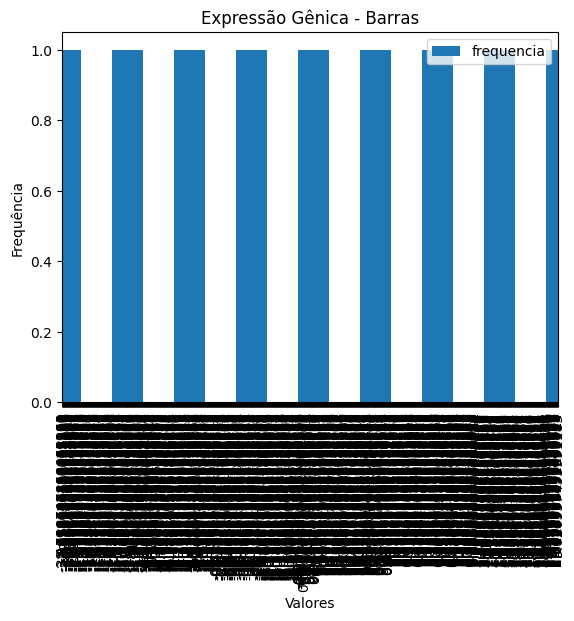

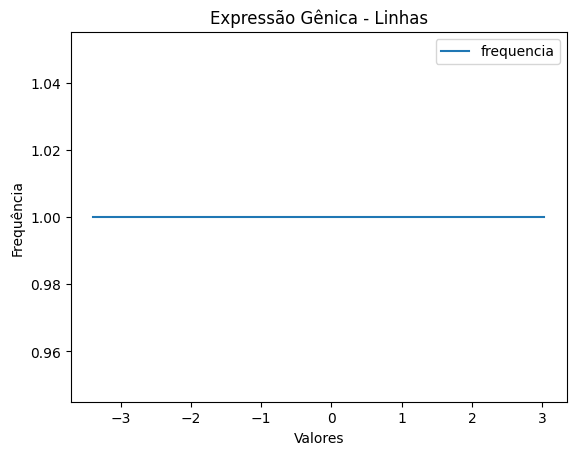

In [8]:
def tabela_frequencia(serie):
    freq = serie.value_counts().sort_index()
    return freq.to_frame(name='frequencia')
freq_exp = tabela_frequencia(pd.Series(expressão_genica))
print(freq_exp.head())
freq_exp.plot(kind='bar')
plt.title('Expressão Gênica - Barras')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

freq_exp.plot(kind='line')
plt.title('Expressão Gênica - Linhas')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

### Número

                                  frequencia
genes_diferencialmente_expressos            
-100                                       5
-99                                        6
-98                                        4
-97                                        6
-96                                        3


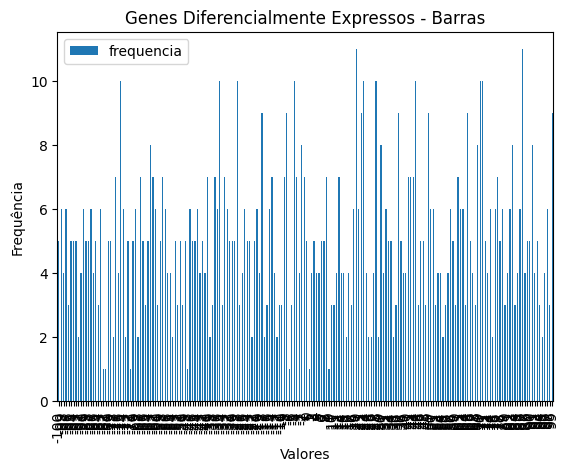

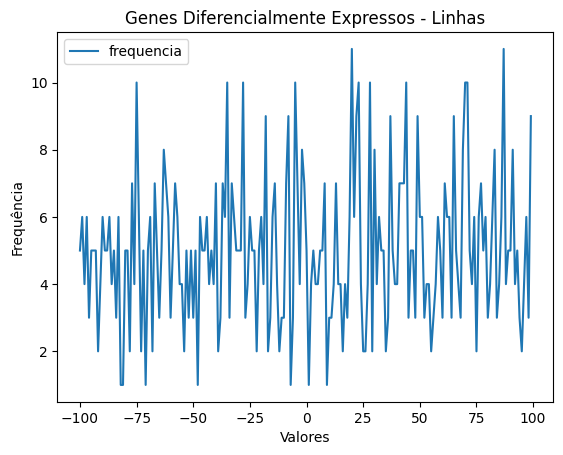

In [9]:
import matplotlib.pyplot as plt
def tabela_frequencia(serie):
    freq = serie.value_counts().sort_index()
    return freq.to_frame(name='frequencia')
freq_genes = tabela_frequencia(df['genes_diferencialmente_expressos'])
print(freq_genes.head())
freq_genes.plot(kind='bar')
plt.title('Genes Diferencialmente Expressos - Barras')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

freq_genes.plot(kind='line')
plt.title('Genes Diferencialmente Expressos - Linhas')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

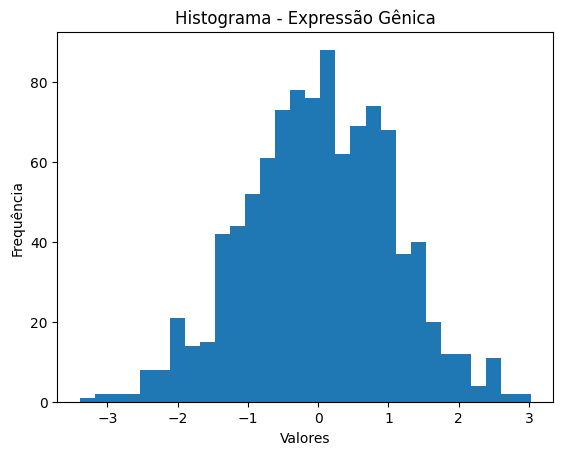

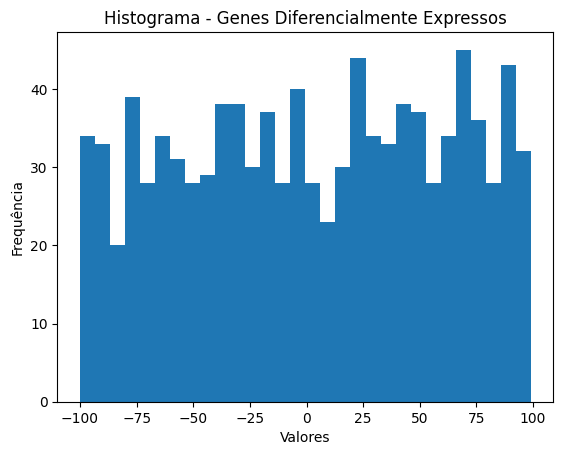

In [10]:
plt.hist(expressão_genica, bins=30)
plt.title('Histograma - Expressão Gênica')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

plt.hist(df['genes_diferencialmente_expressos'], bins=30)
plt.title('Histograma - Genes Diferencialmente Expressos')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

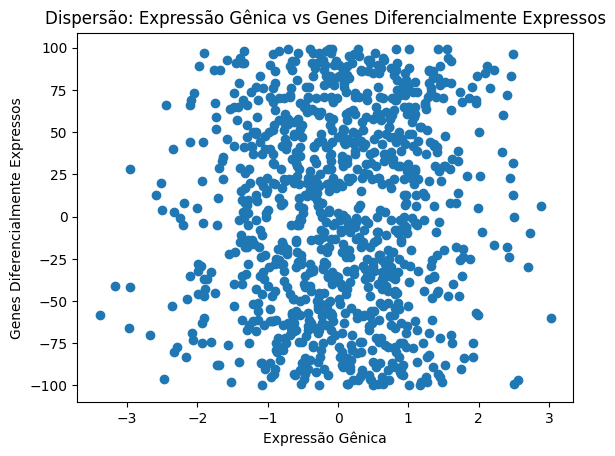

In [11]:
plt.scatter(df['expressao_genica'], df['genes_diferencialmente_expressos'])
plt.title('Dispersão: Expressão Gênica vs Genes Diferencialmente Expressos')
plt.xlabel('Expressão Gênica')
plt.ylabel('Genes Diferencialmente Expressos')
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

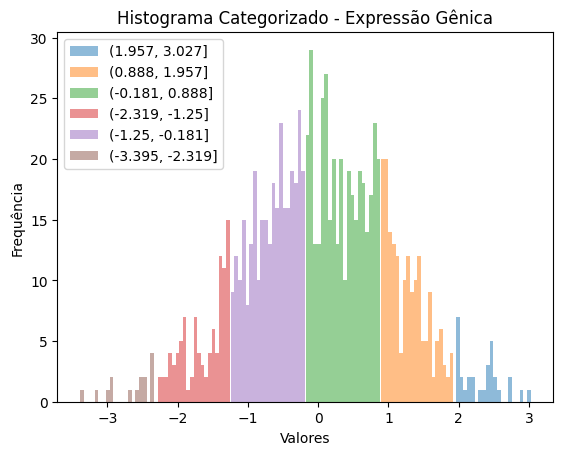

In [13]:
df['grupo'] = pd.cut(df['expressao_genica'], bins=6)
for grupo in df['grupo'].unique():
    dados = df[df['grupo'] == grupo]['expressao_genica']
    plt.hist(dados, bins=20, alpha=0.5, label=str(grupo))
plt.title('Histograma Categorizado - Expressão Gênica')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.legend()
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

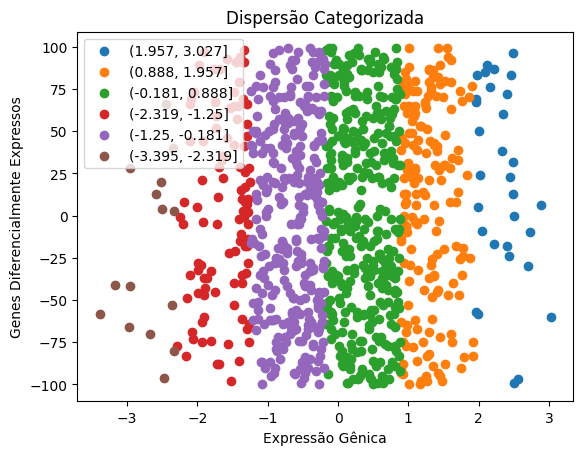

In [14]:
df['grupo'] = pd.cut(df['expressao_genica'], bins=6)
for grupo in df['grupo'].unique():
    dados = df[df['grupo'] == grupo]
    
    plt.scatter(
        dados['expressao_genica'],
        dados['genes_diferencialmente_expressos'],
        label=str(grupo)
    )
plt.title('Dispersão Categorizada')
plt.xlabel('Expressão Gênica')
plt.ylabel('Genes Diferencialmente Expressos')
plt.legend()
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas|Discreta|
| % de células positivas| Continua|
| Faixa de pH|Ordinal|
| Valor de pH|Continua|
| mol/L|Continua|
| UFC|Discreta|
| D.O.|Continua|
| Grupo Sanguíneo|Nominal|
| Sorologia|Nominal|